In [2]:
from environment import Environment
from collections import defaultdict
import pandas as pd
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N = 200000
BATCH_SIZE = 10000
csv_path = "samples.csv"

environment = Environment()
header_written = os.path.exists(csv_path)

batch = defaultdict(list)

for i in range(N):
    # --------------- Sampling
    environment.sample_features()
    environment.update_derived()
    #environment.get_observable_features()

    # --------------- Logging
    #print(i)
    #print(environment.samples.features)

    # --------------- Saving samples
    for key, value in environment.samples.features.items():
        if key not in ("season", "geometry"):
            batch[key].append(value)

    for key, value in environment.derived.items():
        batch[key].append(value)

    batch["impact"].append(environment.impact)

    # Flush to disk every BATCH_SIZE iterations
    if (i + 1) % BATCH_SIZE == 0:
        print (f"Batch {(i + 1) // BATCH_SIZE}")
        df = pd.DataFrame(batch)
        df.to_csv(csv_path, mode="a", index=False, header=not header_written)
        header_written = True
        batch = defaultdict(list)  # free memory

# Write any remaining rows
if batch:
    df = pd.DataFrame(batch)
    df.to_csv(csv_path, mode="a", index=False, header=not header_written)



Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20


In [3]:
summary = df.describe()
summary.to_csv("samples_describe.csv")

In [4]:
'''desc = df.describe().T  # T = transpose

# Reset index so feature names become a regular column
desc.index.name = 'Feature'
desc.reset_index(inplace=True)

# Export to Excel
desc.to_excel('samples_describe.xlsx', index=False)'''

"desc = df.describe().T  # T = transpose\n\n# Reset index so feature names become a regular column\ndesc.index.name = 'Feature'\ndesc.reset_index(inplace=True)\n\n# Export to Excel\ndesc.to_excel('samples_describe.xlsx', index=False)"

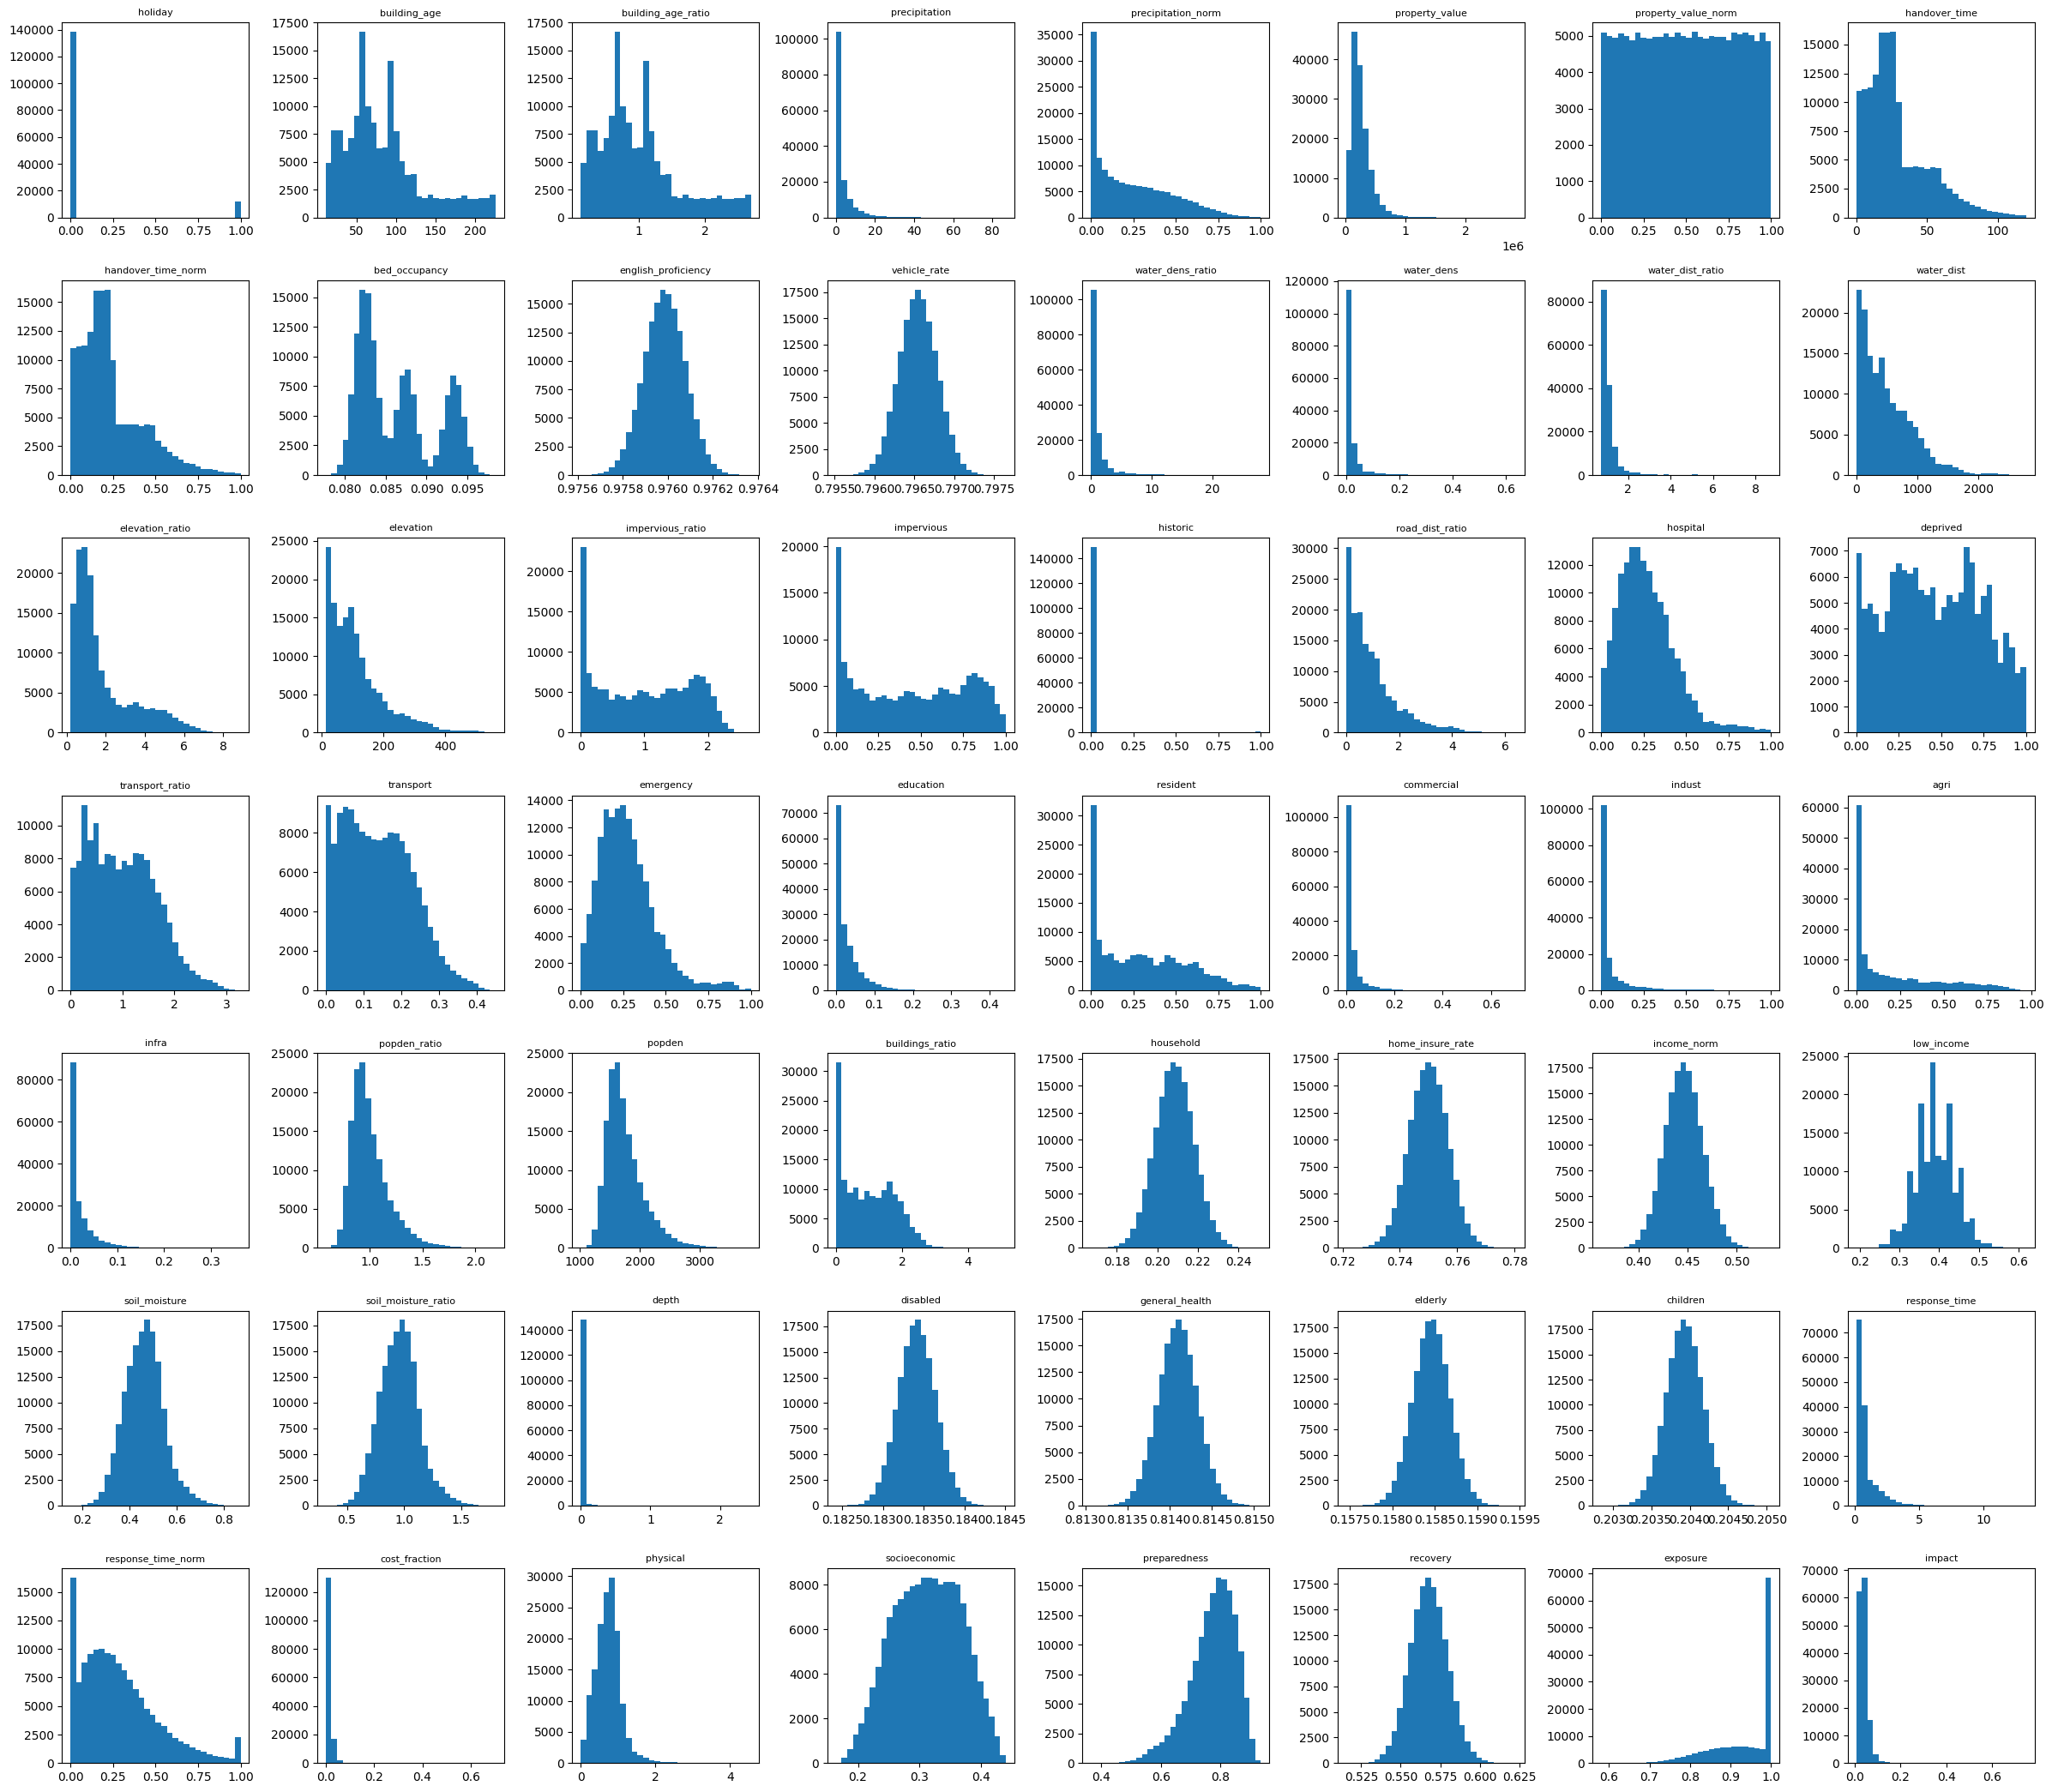

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import math

df = pd.read_csv("samples.csv")

# calculate grid size based on number of columns
n = len(df.columns)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col, fontsize=8)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()